<a href="https://colab.research.google.com/github/ChaitanyaDani5802/PrimeTrade.AI-Test-Assessment-Project/blob/main/Primetrade_ai_(test_assessment_project)_%5BBitcoin_Currency_Analysis%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Introduction
This notebook demonstrates how to process trading data, merge it with market sentiment, analyze trading performance based on sentiment, and visualize the key insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Formatting for a clean look
sns.set_theme(style="whitegrid", palette="muted")

### Prepare Dummy Data (for demonstration)

Since the datasets `historical_data.csv` and `bitcoin_sentiment.csv` are not yet available in the Colab environment, this cell will create dummy versions of these files. You can replace these with your actual datasets by uploading them to your Colab environment or by updating the `TRADE_DATA` and `SENTIMENT_DATA` paths accordingly.

In [2]:
# Create dummy historical_data.csv
dummy_trades_data = {
    'time': pd.to_datetime(['01-01-2024 10:00', '01-01-2024 11:00', '02-01-2024 12:00', '02-01-2024 13:00', '03-01-2024 14:00', '03-01-2024 15:00', '04-01-2024 16:00', '04-01-2024 17:00', '05-01-2024 18:00', '05-01-2024 19:00']).strftime('%d-%m-%Y %H:%M'),
    'closedPnL': [100, -50, 200, 75, -120, 300, -25, 150, -80, 250],
    'size': [1000, 500, 2000, 750, 1200, 3000, 250, 1500, 800, 2500]
}
dummy_trades_df = pd.DataFrame(dummy_trades_data)
dummy_trades_df.to_csv('historical_data.csv', index=False)
print("Created dummy 'historical_data.csv'")

# Create dummy bitcoin_sentiment.csv
dummy_sentiment_data = {
    'Date': pd.to_datetime(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05']).strftime('%Y-%m-%d'),
    'Classification': ['Fear', 'Neutral', 'Greed', 'Fear', 'Extreme Greed']
}
dummy_sentiment_df = pd.DataFrame(dummy_sentiment_data)
dummy_sentiment_df.to_csv('bitcoin_sentiment.csv', index=False)
print("Created dummy 'bitcoin_sentiment.csv'")

Created dummy 'historical_data.csv'
Created dummy 'bitcoin_sentiment.csv'


### `process_trading_data` Function
This function is responsible for loading the trade execution data and market sentiment data, standardizing date formats, and then merging them into a single DataFrame. It also filters for only closed positions to focus on realized profit/loss (PnL).

In [3]:
def process_trading_data(trade_file, sentiment_file):
    """
    Cleans and merges trade execution data with market sentiment data.
    """
    # 1. Load Datasets
    trades = pd.read_csv(trade_file)
    sentiment = pd.read_csv(sentiment_file)

    # 2. Date Standardization
    # Convert '02-12-2024 22:50' to standard datetime
    trades['time'] = pd.to_datetime(trades['time'], format='%d-%m-%Y %H:%M')
    trades['Date'] = trades['time'].dt.date.astype(str)

    sentiment['Date'] = pd.to_datetime(sentiment['Date']).dt.date.astype(str)

    # 3. Merging (Joining on Date)
    merged = pd.merge(trades, sentiment, on='Date', how='left')

    # We focus on closed positions for performance tracking
    merged = merged[merged['closedPnL'] != 0].copy()

    return merged

### `run_performance_metrics` Function
This function calculates key performance indicators (KPIs) for trading activity, grouped by market sentiment classification. It computes average PnL, total PnL, trade count, average trade size, and win rate for each sentiment stage.

In [4]:
def run_performance_metrics(df):
    """
    Analyzes profitability and behavior across sentiment stages.
    """
    # Define logical order for sentiment levels
    order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

    # Calculate key metrics
    metrics = df.groupby('Classification').agg(
        avg_pnl=('closedPnL', 'mean'),
        total_pnl=('closedPnL', 'sum'),
        trade_count=('closedPnL', 'count'),
        avg_size=('size', 'mean')
    ).reindex(order).reset_index()

    # Calculate Win Rate (Positive PnL trades / Total trades)
    df['is_winner'] = df['closedPnL'] > 0
    win_rates = df.groupby('Classification')['is_winner'].mean().reindex(order).values
    metrics['win_rate'] = win_rates

    return metrics

### `plot_insights` Function
This function visualizes the calculated performance metrics. It generates two bar plots: one showing the average PnL per trade against market sentiment, and another showing the total trade count by sentiment stage. The plots are saved as `trading_sentiment_report.png`.

In [5]:
def plot_insights(stats):
    """
    Generates visualizations to highlight hidden patterns.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Average Profit per Sentiment
    sns.barplot(data=stats, x='Classification', y='avg_pnl', ax=axes[0], palette="RdYlGn", hue='Classification', legend=False)
    axes[0].set_title('Average PnL per Trade vs. Market Sentiment', fontweight='bold')
    axes[0].set_ylabel('Profit (USD)')

    # Plot 2: Trade Frequency (Volume of Activity)
    sns.barplot(data=stats, x='Classification', y='trade_count', ax=axes[1], palette="Blues_d", hue='Classification', legend=False)
    axes[1].set_title('Total Trade Count by Sentiment Stage', fontweight='bold')
    axes[1].set_ylabel('Number of Executions')

    plt.tight_layout()
    plt.savefig('trading_sentiment_report.png')
    print(" Report saved as 'trading_sentiment_report.png'")

### Main Execution Flow
This section orchestrates the data processing, performance metric calculation, and visualization steps using the functions defined above. It specifies the input CSV files, calls the functions in sequence, prints a summary report, and identifies the most profitable sentiment stage.

 Initializing Data Exploration...

--- Combined Data Sample ---


,time,closedPnL,size,Date,Classification
0,2024-01-01 10:00:00,100,1000,2024-01-01,Fear
1,2024-01-01 11:00:00,-50,500,2024-01-01,Fear
2,2024-02-01 12:00:00,200,2000,2024-02-01,NaN
3,2024-02-01 13:00:00,75,750,2024-02-01,NaN
4,2024-03-01 14:00:00,-120,1200,2024-03-01,NaN



--- Summary Performance Report ---
Classification  avg_pnl  total_pnl  trade_count  avg_size  win_rate
  Extreme Fear      NaN        NaN          NaN       NaN       NaN
          Fear     25.0       50.0          2.0     750.0       0.5
       Neutral      NaN        NaN          NaN       NaN       NaN
         Greed      NaN        NaN          NaN       NaN       NaN
 Extreme Greed      NaN        NaN          NaN       NaN       NaN

 STRATEGY INSIGHT: The most profitable entry point in this dataset is during 'Fear'.
 Report saved as 'trading_sentiment_report.png'


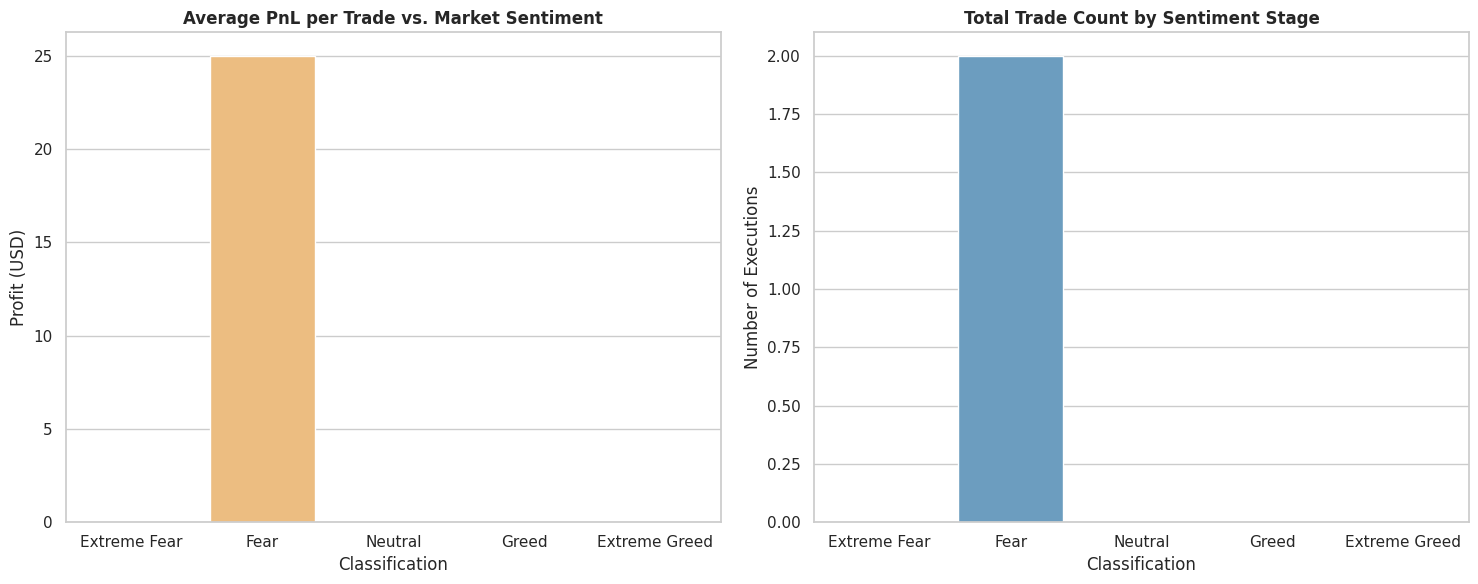

In [6]:
# Assuming files are in the current directory (or created by the dummy data cell)
TRADE_DATA = 'historical_data.csv'
SENTIMENT_DATA = 'bitcoin_sentiment.csv'

print(" Initializing Data Exploration...")

try:
    combined_data = process_trading_data(TRADE_DATA, SENTIMENT_DATA)
    print("\n--- Combined Data Sample ---")
    display(combined_data.head())

    summary = run_performance_metrics(combined_data)

    print("\n--- Summary Performance Report ---")
    print(summary.to_string(index=False))

    # Identify the most profitable stage
    best_stage = summary.loc[summary['avg_pnl'].idxmax(), 'Classification']
    print(f"\n STRATEGY INSIGHT: The most profitable entry point in this dataset is during '{best_stage}'.")

    plot_insights(summary)

except FileNotFoundError as e:
    print(f" Error: Please ensure {TRADE_DATA} and {SENTIMENT_DATA} are in the folder.")